# Target 10m Model Experiments Overview

Обзор результатов staged hold-out перебора моделей для `target_log_return_10m`.

Локальные входные файлы скачаны из:

`s3://binance-data-downloader/dataset_target_10/model_experiments/latest/`

In [73]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 180)
plt.style.use("seaborn-v0_8-whitegrid")

RESULTS_DIR = Path("analysis/target_20_model_experiments/results/latest")
if not RESULTS_DIR.exists():
    RESULTS_DIR = Path("results/latest")

results = pd.read_parquet(RESULTS_DIR / "experiment_results.parquet")
stage_selection = pd.read_parquet(RESULTS_DIR / "stage_selection.parquet")
run_config = json.loads((RESULTS_DIR / "run_config.json").read_text(encoding="utf-8"))

results.shape, stage_selection.shape

((994, 42), (6, 9))

## Run Summary

In [74]:
summary_keys = [
    "run_id",
    "target",
    "direction_threshold",
    "train_rows",
    "test_rows",
    "n_jobs",
    "parallel_backend",
    "max_selected_per_stage",
]
pd.DataFrame(
    [{"field": key, "value": run_config.get(key)} for key in summary_keys]
)

,field,value
0,run_id,20260705_163911
1,target,target_log_return_10m
2,direction_threshold,0.0025
3,train_rows,2630700
4,test_rows,527040
5,n_jobs,24
6,parallel_backend,threading
7,max_selected_per_stage,6


In [75]:
stage_selection

,stage,stage_index,candidates,selected,selected_model_ids,n_jobs,parallel_backend,prep_time,prepared_features
0,stage_0_baseline,0,2,2,"[""stage_0_baseline_001_baseline_zero"", ""stage_0_baseline_002_baseline_mean""]",24,threading,2.275382,56
1,stage_1_ar,1,40,6,"[""stage_1_ar_003_lasso_alpha_1e_5"", ""stage_1_ar_004_lasso_alpha_1e_5"", ""stage_1_ar_005_lasso_alpha_1e_5"", ""stage_1_ar_004_huber"", ""stage_1_ar_005_huber"", ""stage_1_ar_003_ols""]",24,threading,2.275382,56
2,stage_2_price_volatility,2,144,6,"[""stage_2_price_volatility_006_lasso_alpha_1e_5"", ""stage_2_price_volatility_015_lasso_alpha_1e_5"", ""stage_2_price_volatility_007_lasso_alpha_1e_5"", ""stage_2_price_volatility_00...",24,threading,2.275382,56
3,stage_3_microstructure,3,320,6,"[""stage_3_microstructure_002_lasso_alpha_1e_5"", ""stage_3_microstructure_008_lasso_alpha_1e_5"", ""stage_3_microstructure_026_lasso_alpha_1e_5"", ""stage_3_microstructure_008_huber""...",24,threading,2.275382,56
4,stage_4_btc,4,200,6,"[""stage_4_btc_001_lasso_alpha_1e_5"", ""stage_4_btc_006_lasso_alpha_1e_5"", ""stage_4_btc_016_lasso_alpha_1e_5"", ""stage_4_btc_013_huber"", ""stage_4_btc_008_huber"", ""stage_4_btc_011_...",24,threading,2.275382,56
5,stage_5_calendar_sessions,5,288,6,"[""stage_5_calendar_sessions_006_lasso_alpha_1e_5"", ""stage_5_calendar_sessions_005_lasso_alpha_1e_5"", ""stage_5_calendar_sessions_004_lasso_alpha_1e_5"", ""stage_5_calendar_session...",24,threading,2.275382,56


## Global Top Models

In [76]:
display_cols = [
    "model_id",
    "stage",
    "model_family",
    "feature_set",
    "n_features",
    "MAE",
    "RMSE",
    "Direction_Accuracy",
    "Direction_Accuracy_025",
    "DA_025_coverage",
    "OOS_R2",
    "Pearson_corr",
]

top_a = results.sort_values(
    ["MAE", "RMSE", "n_features", "simplicity_rank", "model_id"],
    ascending=[True, True, True, True, True],
).head(15)

top_b = results.sort_values(
    ["Direction_Accuracy_025", "n_features", "simplicity_rank", "model_id"],
    ascending=[False, True, True, True],
    na_position="last",
).head(15)

top_a[display_cols]

,model_id,stage,model_family,feature_set,n_features,MAE,RMSE,Direction_Accuracy,Direction_Accuracy_025,DA_025_coverage,OOS_R2,Pearson_corr
750,stage_5_calendar_sessions_006_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+trades_only+btc_returns_only+all_calendar_sessions,21,0.002704,0.005219,0.514451,0.514944,0.385474,0.011279,0.137813
742,stage_5_calendar_sessions_005_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+trades_only+btc_returns_only+day_sessions,19,0.002704,0.005219,0.514451,0.514944,0.385474,0.011279,0.137813
734,stage_5_calendar_sessions_004_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+trades_only+btc_returns_only+time_sessions,18,0.002704,0.005219,0.514445,0.514973,0.385474,0.011278,0.137807
726,stage_5_calendar_sessions_003_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+trades_only+btc_returns_only+sessions,16,0.002704,0.005219,0.514445,0.514973,0.385474,0.011278,0.137807
774,stage_5_calendar_sessions_009_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+all_microstructure+btc_returns_only+sessions,29,0.002704,0.005220,0.514279,0.514698,0.385474,0.010931,0.133331
790,stage_5_calendar_sessions_011_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+all_microstructure+btc_returns_only+day_sessions,32,0.002704,0.005220,0.514279,0.514698,0.385474,0.010931,0.133331
782,stage_5_calendar_sessions_010_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+all_microstructure+btc_returns_only+time_sessions,31,0.002704,0.005220,0.514279,0.514698,0.385474,0.010931,0.133331
798,stage_5_calendar_sessions_012_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+all_microstructure+btc_returns_only+all_calendar_sessions,34,0.002704,0.005220,0.514279,0.514698,0.385474,0.010931,0.133331
990,stage_5_calendar_sessions_036_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_10+trend_volatility+trades_only+btc_returns_only+all_calendar_sessions,22,0.002704,0.005219,0.514340,0.514786,0.385474,0.011274,0.137584
982,stage_5_calendar_sessions_035_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_10+trend_volatility+trades_only+btc_returns_only+day_sessions,20,0.002704,0.005219,0.514340,0.514786,0.385474,0.011274,0.137584


In [77]:
top_b[display_cols]

,model_id,stage,model_family,feature_set,n_features,MAE,RMSE,Direction_Accuracy,Direction_Accuracy_025,DA_025_coverage,OOS_R2,Pearson_corr
945,stage_5_calendar_sessions_030_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+trend_volatility_efficiency+all_microstructure+btc_efficiency_only+all_calendar_sessions,35,0.002705,0.005217,0.516217,0.516425,0.385474,0.012067,0.114466
809,stage_5_calendar_sessions_013_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+trend_volatility+all_microstructure+btc_efficiency_only+time_of_day,28,0.002705,0.005217,0.516147,0.516411,0.385474,0.011897,0.113506
833,stage_5_calendar_sessions_016_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+trend_volatility+all_microstructure+btc_efficiency_only+time_sessions,30,0.002705,0.005217,0.516525,0.516401,0.385474,0.012070,0.114391
849,stage_5_calendar_sessions_018_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+trend_volatility+all_microstructure+btc_efficiency_only+all_calendar_sessions,33,0.002705,0.005217,0.516371,0.516332,0.385474,0.011997,0.114099
889,stage_5_calendar_sessions_023_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+trend_volatility_efficiency+all_microstructure+btc_returns_only+day_sessions,34,0.002705,0.005216,0.516248,0.516327,0.385474,0.012246,0.115517
929,stage_5_calendar_sessions_028_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+trend_volatility_efficiency+all_microstructure+btc_efficiency_only+time_sessions,32,0.002705,0.005217,0.516476,0.516317,0.385474,0.012034,0.114382
801,stage_5_calendar_sessions_012_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+trend_volatility+all_microstructure+btc_returns_only+all_calendar_sessions,34,0.002705,0.005217,0.516159,0.516273,0.385474,0.012089,0.114695
737,stage_5_calendar_sessions_004_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+trend_volatility+trades_only+btc_returns_only+time_sessions,18,0.002705,0.005217,0.516463,0.516253,0.385474,0.012082,0.114025
897,stage_5_calendar_sessions_024_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+trend_volatility_efficiency+all_microstructure+btc_returns_only+all_calendar_sessions,36,0.002705,0.005217,0.516122,0.516219,0.385474,0.012166,0.115130
977,stage_5_calendar_sessions_034_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_10+trend_volatility+trades_only+btc_returns_only+time_sessions,19,0.002705,0.005217,0.516461,0.516214,0.385474,0.012080,0.113995


## Best Model By Stage

In [78]:
best_mae_by_stage = (
    results.sort_values(["stage", "MAE", "RMSE", "n_features", "simplicity_rank"])
    .groupby("stage", as_index=False)
    .first()
)

best_da_by_stage = (
    results.sort_values(
        ["stage", "Direction_Accuracy_025", "n_features", "simplicity_rank"],
        ascending=[True, False, True, True],
        na_position="last",
    )
    .groupby("stage", as_index=False)
    .first()
)

best_mae_by_stage[display_cols]

,model_id,stage,model_family,feature_set,n_features,MAE,RMSE,Direction_Accuracy,Direction_Accuracy_025,DA_025_coverage,OOS_R2,Pearson_corr
0,stage_0_baseline_001_baseline_zero,stage_0_baseline,baseline_zero,baseline_zero,0,0.002707,0.005249,0.494219,0.000000,0.385474,0.000000,NaN
1,stage_1_ar_003_lasso_alpha_1e_5,stage_1_ar,lasso_alpha_1e_5,baseline_zero+ar_5,4,0.002706,0.005248,0.507236,0.508634,0.385474,0.000358,0.020965
2,stage_2_price_volatility_006_lasso_alpha_1e_5,stage_2_price_volatility,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility,10,0.002704,0.005220,0.514038,0.514068,0.385474,0.010717,0.130613
3,stage_3_microstructure_002_lasso_alpha_1e_5,stage_3_microstructure,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+trades_only,12,0.002704,0.005219,0.514435,0.514772,0.385474,0.011261,0.137301
4,stage_4_btc_001_lasso_alpha_1e_5,stage_4_btc,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+trades_only+btc_returns_only,14,0.002704,0.005219,0.514318,0.514649,0.385474,0.011184,0.136909
5,stage_5_calendar_sessions_006_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+trades_only+btc_returns_only+all_calendar_sessions,21,0.002704,0.005219,0.514451,0.514944,0.385474,0.011279,0.137813


In [79]:
best_da_by_stage[display_cols]

,model_id,stage,model_family,feature_set,n_features,MAE,RMSE,Direction_Accuracy,Direction_Accuracy_025,DA_025_coverage,OOS_R2,Pearson_corr
0,stage_0_baseline_002_baseline_mean,stage_0_baseline,baseline_mean,baseline_mean,0,0.002707,0.005249,0.494219,0.494339,0.385474,-0.000022,NaN
1,stage_1_ar_004_huber,stage_1_ar,huber,baseline_zero+ar_10,5,0.002707,0.005248,0.508241,0.510883,0.385474,0.000324,0.024483
2,stage_2_price_volatility_009_huber,stage_2_price_volatility,huber,baseline_zero+ar_5+all_price_volatility,29,0.002705,0.005213,0.514784,0.515795,0.385474,0.013534,0.120097
3,stage_3_microstructure_008_huber,stage_3_microstructure,huber,baseline_zero+ar_5+trend_volatility+all_microstructure,25,0.002705,0.005217,0.515972,0.516002,0.385474,0.012215,0.115208
4,stage_4_btc_013_huber,stage_4_btc,huber,baseline_zero+ar_5+trend_volatility_efficiency+all_microstructure+btc_efficiency_only,28,0.002705,0.005218,0.515900,0.516120,0.385474,0.011542,0.111591
5,stage_5_calendar_sessions_030_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+trend_volatility_efficiency+all_microstructure+btc_efficiency_only+all_calendar_sessions,35,0.002705,0.005217,0.516217,0.516425,0.385474,0.012067,0.114466


### Full Parameters For Global Best Models

In [80]:
best_model_specs = {
    "best_MAE": results.sort_values(
        ["MAE", "RMSE", "n_features", "simplicity_rank", "model_id"],
        ascending=[True, True, True, True, True],
        na_position="last",
    ).iloc[0],
    "best_RMSE": results.sort_values(
        ["RMSE", "MAE", "n_features", "simplicity_rank", "model_id"],
        ascending=[True, True, True, True, True],
        na_position="last",
    ).iloc[0],
    "best_Direction_Accuracy_025": results.sort_values(
        ["Direction_Accuracy_025", "n_features", "simplicity_rank", "model_id"],
        ascending=[False, True, True, True],
        na_position="last",
    ).iloc[0],
}

best_model_full_params = pd.concat(
    [row.rename(winner_by).to_frame().T for winner_by, row in best_model_specs.items()],
    axis=0,
)

best_model_full_params.T.rename_axis("parameter")

,best_MAE,best_RMSE,best_Direction_Accuracy_025
parameter,,,
model_id,stage_5_calendar_sessions_006_lasso_alpha_1e_5,stage_3_microstructure_040_ols,stage_5_calendar_sessions_030_huber
stage,stage_5_calendar_sessions,stage_3_microstructure,stage_5_calendar_sessions
model_family,lasso_alpha_1e_5,ols,huber
model_name,baseline_zero+ar_5+trend_volatility+trades_only+btc_returns_only+all_calendar_sessions__lasso_alpha_1e_5,baseline_zero+ar_10+all_price_volatility+all_microstructure__ols,baseline_zero+ar_5+trend_volatility_efficiency+all_microstructure+btc_efficiency_only+all_calendar_sessions__huber
feature_set,baseline_zero+ar_5+trend_volatility+trades_only+btc_returns_only+all_calendar_sessions,baseline_zero+ar_10+all_price_volatility+all_microstructure,baseline_zero+ar_5+trend_volatility_efficiency+all_microstructure+btc_efficiency_only+all_calendar_sessions
features,"[""ada_log_return_lag_1"", ""ada_log_return_lag_2"", ""ada_log_return_lag_3"", ""ada_log_return_lag_5"", ""ada_cum_return_30m"", ""ada_cum_return_60m"", ""ada_return_std_20m"", ""ada_return_s...","[""ada_log_return_lag_1"", ""ada_log_return_lag_2"", ""ada_log_return_lag_3"", ""ada_log_return_lag_5"", ""ada_log_return_lag_10"", ""ada_cum_return_30m"", ""ada_cum_return_60m"", ""ada_retur...","[""ada_log_return_lag_1"", ""ada_log_return_lag_2"", ""ada_log_return_lag_3"", ""ada_log_return_lag_5"", ""ada_cum_return_30m"", ""ada_cum_return_60m"", ""ada_return_std_20m"", ""ada_return_s..."
n_features,21,45,35
train_size,2630700,2630700,2630700
test_size,527040,527040,527040


### Cross-Horizon Top Feature Comparison

In [81]:
def find_project_root_for_results(start=None):
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "build_price_feature_day.py").exists():
            return candidate
    return Path.cwd().resolve()


PROJECT_ROOT_FOR_RESULTS = find_project_root_for_results()
EXPERIMENT_DIR_FOR_RESULTS = PROJECT_ROOT_FOR_RESULTS / "analysis" / "target_10_model_experiments"

HORIZON_RESULT_DIRS_FOR_COMPARISON = {
    10: [
        EXPERIMENT_DIR_FOR_RESULTS / "results" / "target_10" / "latest",
        EXPERIMENT_DIR_FOR_RESULTS / "results" / "latest",
        Path("results/latest"),
    ],
    20: [
        EXPERIMENT_DIR_FOR_RESULTS / "results" / "target_20" / "latest",
        EXPERIMENT_DIR_FOR_RESULTS / "analysis" / "target_10_model_experiments" / "results" / "target_20" / "latest",
        PROJECT_ROOT_FOR_RESULTS / "analysis" / "target_20_model_experiments" / "results" / "latest",
        Path("results/target_20/latest"),
    ],
    30: [
        EXPERIMENT_DIR_FOR_RESULTS / "results" / "target_30" / "latest",
        EXPERIMENT_DIR_FOR_RESULTS / "analysis" / "target_10_model_experiments" / "results" / "target_30" / "latest",
        PROJECT_ROOT_FOR_RESULTS / "analysis" / "target_30_model_experiments" / "results" / "latest",
        Path("results/target_30/latest"),
    ],
}


def first_existing_results_dir_for_comparison(candidates):
    for candidate in candidates:
        if (candidate / "experiment_results.parquet").exists():
            return candidate
    return None


def load_horizon_results_for_comparison():
    frames = {}
    missing = []
    for horizon, candidates in HORIZON_RESULT_DIRS_FOR_COMPARISON.items():
        horizon_dir = first_existing_results_dir_for_comparison(candidates)
        if horizon_dir is None:
            missing.append(horizon)
            continue
        frames[horizon] = pd.read_parquet(horizon_dir / "experiment_results.parquet")
    if missing:
        print("Missing local results for horizons:", missing)
    return frames


def parse_feature_list(value):
    if isinstance(value, str):
        return json.loads(value)
    return list(value or [])


def pick_absolute_top_models(frame, scope_label):
    specs = {
        "best_MAE": (
            ["MAE", "RMSE", "n_features", "simplicity_rank", "model_id"],
            [True, True, True, True, True],
            "MAE",
        ),
        "best_RMSE": (
            ["RMSE", "MAE", "n_features", "simplicity_rank", "model_id"],
            [True, True, True, True, True],
            "RMSE",
        ),
        "best_Direction_Accuracy_025": (
            ["Direction_Accuracy_025", "n_features", "simplicity_rank", "model_id"],
            [False, True, True, True],
            "Direction_Accuracy_025",
        ),
    }

    rows = []
    for winner_by, (sort_cols, ascending, metric) in specs.items():
        row = frame.sort_values(sort_cols, ascending=ascending, na_position="last").iloc[0]
        features = parse_feature_list(row["features"])
        rows.append(
            {
                "scope": scope_label,
                "winner_by": winner_by,
                "model_id": row["model_id"],
                "stage": row["stage"],
                "model_family": row["model_family"],
                "feature_set": row["feature_set"],
                "metric": metric,
                "metric_value": row[metric],
                "n_features": len(features),
                "features": features,
            }
        )
    return rows


def build_top_feature_rows(frames_by_horizon, stage_filter=None, scope_label="global"):
    rows = []
    for horizon, frame in sorted(frames_by_horizon.items()):
        scoped = frame if stage_filter is None else frame.query("stage == @stage_filter")
        if scoped.empty:
            continue
        for row in pick_absolute_top_models(scoped, scope_label):
            row["horizon"] = horizon
            rows.append(row)
    return pd.DataFrame(rows)


def summarize_feature_occurrence(top_models):
    exploded = (
        top_models[["horizon", "scope", "winner_by", "model_id", "features"]]
        .explode("features")
        .rename(columns={"features": "feature"})
        .dropna(subset=["feature"])
    )
    if exploded.empty:
        return exploded

    summary = (
        exploded.groupby("feature")
        .agg(
            horizons=("horizon", lambda values: sorted(set(values))),
            n_horizons=("horizon", "nunique"),
            appearances=("feature", "size"),
            winner_types=("winner_by", lambda values: sorted(set(values))),
            models=("model_id", lambda values: sorted(set(values))),
        )
        .reset_index()
        .sort_values(["n_horizons", "appearances", "feature"], ascending=[False, False, True])
    )
    summary["horizons"] = summary["horizons"].apply(lambda values: ", ".join(f"{value}m" for value in values))
    summary["winner_types"] = summary["winner_types"].apply(lambda values: ", ".join(values))
    summary["models"] = summary["models"].apply(lambda values: ", ".join(values))
    return summary


def display_cross_horizon_feature_comparison(top_models, title):
    summary_cols = [
        "horizon",
        "winner_by",
        "model_id",
        "stage",
        "model_family",
        "feature_set",
        "metric_value",
        "n_features",
    ]
    print(f"\n=== {title}: absolute top models by horizon ===")
    display(top_models[summary_cols])

    occurrence = summarize_feature_occurrence(top_models)
    print(f"\n=== {title}: factors appearing in absolute top across horizons ===")
    display(occurrence)

    print(f"\n=== {title}: factors appearing in exactly one horizon ===")
    display(occurrence.query("n_horizons == 1"))

    print(f"\n=== {title}: factors appearing in exactly two horizons ===")
    display(occurrence.query("n_horizons == 2"))

    print(f"\n=== {title}: factors appearing in all available horizons ===")
    display(occurrence.query("n_horizons == @top_models['horizon'].nunique()"))

    return occurrence


frames_by_horizon = load_horizon_results_for_comparison()

global_top_models = build_top_feature_rows(frames_by_horizon, stage_filter=None, scope_label="global")
stage_3_top_models = build_top_feature_rows(
    frames_by_horizon,
    stage_filter="stage_3_microstructure",
    scope_label="stage_3_microstructure",
)

global_feature_occurrence = display_cross_horizon_feature_comparison(
    global_top_models,
    "Global winners",
)
stage_3_feature_occurrence = display_cross_horizon_feature_comparison(
    stage_3_top_models,
    "Stage 3 winners",
)



=== Global winners: absolute top models by horizon ===


,horizon,winner_by,model_id,stage,model_family,feature_set,metric_value,n_features
0,10,best_MAE,stage_5_calendar_sessions_006_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+trades_only+btc_returns_only+all_calendar_sessions,0.002704,21
1,10,best_RMSE,stage_3_microstructure_040_ols,stage_3_microstructure,ols,baseline_zero+ar_10+all_price_volatility+all_microstructure,0.005202,45
2,10,best_Direction_Accuracy_025,stage_5_calendar_sessions_030_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+trend_volatility_efficiency+all_microstructure+btc_efficiency_only+all_calendar_sessions,0.516425,35
3,20,best_MAE,stage_5_calendar_sessions_009_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_10+trend_volatility_efficiency+all_microstructure+btc_returns_only+sessions,0.003809,33
4,20,best_RMSE,stage_3_microstructure_024_ols,stage_3_microstructure,ols,baseline_zero+ar_10+all_price_volatility+all_microstructure,0.007077,45
5,20,best_Direction_Accuracy_025,stage_5_calendar_sessions_019_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_10+all_price_volatility+concentration_only+btc_efficiency_only+time_of_day,0.525176,36
6,30,best_MAE,stage_5_calendar_sessions_009_ridge_alpha_10,stage_5_calendar_sessions,ridge_alpha_10,baseline_zero+ar_5+trend_volatility_efficiency+concentration_only+all_btc+sessions,0.004647,22
7,30,best_RMSE,stage_3_microstructure_047_ols,stage_3_microstructure,ols,baseline_zero+ar_10+all_price_volatility+aggression_concentration,0.008470,36
8,30,best_Direction_Accuracy_025,stage_5_calendar_sessions_029_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+candle_geometry+aggression_concentration+btc_volatility_only+day_sessions,0.525509,29



=== Global winners: factors appearing in absolute top across horizons ===


,feature,horizons,n_horizons,appearances,winner_types,models
21,ada_log_return_lag_1,"10m, 20m, 30m",3,9,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_024_ols, stage_3_microstructure_040_ols, stage_3_microstructure_047_ols, stage_5_calendar_sessions_006_lasso_alpha_1e_5, stage_5_calendar_sessions_009_la..."
23,ada_log_return_lag_2,"10m, 20m, 30m",3,9,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_024_ols, stage_3_microstructure_040_ols, stage_3_microstructure_047_ols, stage_5_calendar_sessions_006_lasso_alpha_1e_5, stage_5_calendar_sessions_009_la..."
24,ada_log_return_lag_3,"10m, 20m, 30m",3,9,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_024_ols, stage_3_microstructure_040_ols, stage_3_microstructure_047_ols, stage_5_calendar_sessions_006_lasso_alpha_1e_5, stage_5_calendar_sessions_009_la..."
25,ada_log_return_lag_5,"10m, 20m, 30m",3,9,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_024_ols, stage_3_microstructure_040_ols, stage_3_microstructure_047_ols, stage_5_calendar_sessions_006_lasso_alpha_1e_5, stage_5_calendar_sessions_009_la..."
10,ada_cum_return_30m,"10m, 20m, 30m",3,8,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_024_ols, stage_3_microstructure_040_ols, stage_3_microstructure_047_ols, stage_5_calendar_sessions_006_lasso_alpha_1e_5, stage_5_calendar_sessions_009_la..."
11,ada_cum_return_60m,"10m, 20m, 30m",3,8,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_024_ols, stage_3_microstructure_040_ols, stage_3_microstructure_047_ols, stage_5_calendar_sessions_006_lasso_alpha_1e_5, stage_5_calendar_sessions_009_la..."
14,ada_inverse_simpson_norm_30m,"10m, 20m, 30m",3,8,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_024_ols, stage_3_microstructure_040_ols, stage_3_microstructure_047_ols, stage_5_calendar_sessions_009_lasso_alpha_1e_5, stage_5_calendar_sessions_009_ri..."
28,ada_pressure_concentration_30m,"10m, 20m, 30m",3,8,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_024_ols, stage_3_microstructure_040_ols, stage_3_microstructure_047_ols, stage_5_calendar_sessions_009_lasso_alpha_1e_5, stage_5_calendar_sessions_009_ri..."
29,ada_pressure_concentration_5m,"10m, 20m, 30m",3,8,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_024_ols, stage_3_microstructure_040_ols, stage_3_microstructure_047_ols, stage_5_calendar_sessions_009_lasso_alpha_1e_5, stage_5_calendar_sessions_009_ri..."
30,ada_realized_volatility_20m,"10m, 20m, 30m",3,8,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_024_ols, stage_3_microstructure_040_ols, stage_3_microstructure_047_ols, stage_5_calendar_sessions_006_lasso_alpha_1e_5, stage_5_calendar_sessions_009_la..."



=== Global winners: factors appearing in exactly one horizon ===


...

,feature,horizons,n_horizons,appearances,winner_types,models
0,ada_aggression_delta_norm_10m,20m,1,2,"best_MAE, best_RMSE","stage_3_microstructure_016_lasso_alpha_1e_5, stage_3_microstructure_024_ols"
42,ada_upper_wick_60m,20m,1,2,"best_Direction_Accuracy_025, best_RMSE","stage_3_microstructure_020_huber, stage_3_microstructure_024_ols"
45,ada_volume_sum_20m,10m,1,2,"best_Direction_Accuracy_025, best_RMSE","stage_3_microstructure_008_huber, stage_3_microstructure_040_ols"
46,ada_volume_sum_30m,20m,1,2,"best_MAE, best_RMSE","stage_3_microstructure_016_lasso_alpha_1e_5, stage_3_microstructure_024_ols"
31,ada_realized_volatility_5m,10m,1,1,best_RMSE,stage_3_microstructure_040_ols



=== Stage 3 winners: factors appearing in exactly two horizons ===


,feature,horizons,n_horizons,appearances,winner_types,models
38,ada_trades_per_minute_30m,"10m, 20m",2,5,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_002_lasso_alpha_1e_5, stage_3_microstructure_008_huber, stage_3_microstructure_016_lasso_alpha_1e_5, stage_3_microstructure_024_ols, stage_3_microstructu..."
39,ada_trades_per_minute_5m,"10m, 20m",2,5,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_002_lasso_alpha_1e_5, stage_3_microstructure_008_huber, stage_3_microstructure_016_lasso_alpha_1e_5, stage_3_microstructure_024_ols, stage_3_microstructu..."
3,ada_average_trade_size_quote_10m,"10m, 20m",2,4,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_008_huber, stage_3_microstructure_016_lasso_alpha_1e_5, stage_3_microstructure_024_ols, stage_3_microstructure_040_ols"
4,ada_average_trade_size_quote_30m,"10m, 20m",2,4,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_008_huber, stage_3_microstructure_016_lasso_alpha_1e_5, stage_3_microstructure_024_ols, stage_3_microstructure_040_ols"
44,ada_volume_sum_10m,"10m, 20m",2,4,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_008_huber, stage_3_microstructure_016_lasso_alpha_1e_5, stage_3_microstructure_024_ols, stage_3_microstructure_040_ols"
47,ada_volume_zscore_60m,"10m, 20m",2,4,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_008_huber, stage_3_microstructure_016_lasso_alpha_1e_5, stage_3_microstructure_024_ols, stage_3_microstructure_040_ols"
35,ada_return_acceleration_5m,"10m, 20m",2,3,"best_Direction_Accuracy_025, best_RMSE","stage_3_microstructure_020_huber, stage_3_microstructure_024_ols, stage_3_microstructure_040_ols"
40,ada_upper_wick_30m,"10m, 30m",2,3,"best_Direction_Accuracy_025, best_RMSE","stage_3_microstructure_023_huber, stage_3_microstructure_040_ols, stage_3_microstructure_047_ols"



=== Stage 3 winners: factors appearing in all available horizons ===


,feature,horizons,n_horizons,appearances,winner_types,models
21,ada_log_return_lag_1,"10m, 20m, 30m",3,9,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_002_lasso_alpha_1e_5, stage_3_microstructure_008_huber, stage_3_microstructure_012_ridge_alpha_10, stage_3_microstructure_016_lasso_alpha_1e_5, stage_3_m..."
23,ada_log_return_lag_2,"10m, 20m, 30m",3,9,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_002_lasso_alpha_1e_5, stage_3_microstructure_008_huber, stage_3_microstructure_012_ridge_alpha_10, stage_3_microstructure_016_lasso_alpha_1e_5, stage_3_m..."
24,ada_log_return_lag_3,"10m, 20m, 30m",3,9,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_002_lasso_alpha_1e_5, stage_3_microstructure_008_huber, stage_3_microstructure_012_ridge_alpha_10, stage_3_microstructure_016_lasso_alpha_1e_5, stage_3_m..."
25,ada_log_return_lag_5,"10m, 20m, 30m",3,9,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_002_lasso_alpha_1e_5, stage_3_microstructure_008_huber, stage_3_microstructure_012_ridge_alpha_10, stage_3_microstructure_016_lasso_alpha_1e_5, stage_3_m..."
10,ada_cum_return_30m,"10m, 20m, 30m",3,8,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_002_lasso_alpha_1e_5, stage_3_microstructure_008_huber, stage_3_microstructure_012_ridge_alpha_10, stage_3_microstructure_016_lasso_alpha_1e_5, stage_3_m..."
11,ada_cum_return_60m,"10m, 20m, 30m",3,8,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_002_lasso_alpha_1e_5, stage_3_microstructure_008_huber, stage_3_microstructure_012_ridge_alpha_10, stage_3_microstructure_016_lasso_alpha_1e_5, stage_3_m..."
14,ada_inverse_simpson_norm_30m,"10m, 20m, 30m",3,8,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_008_huber, stage_3_microstructure_012_ridge_alpha_10, stage_3_microstructure_016_lasso_alpha_1e_5, stage_3_microstructure_020_huber, stage_3_microstructu..."
28,ada_pressure_concentration_30m,"10m, 20m, 30m",3,8,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_008_huber, stage_3_microstructure_012_ridge_alpha_10, stage_3_microstructure_016_lasso_alpha_1e_5, stage_3_microstructure_020_huber, stage_3_microstructu..."
29,ada_pressure_concentration_5m,"10m, 20m, 30m",3,8,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_008_huber, stage_3_microstructure_012_ridge_alpha_10, stage_3_microstructure_016_lasso_alpha_1e_5, stage_3_microstructure_020_huber, stage_3_microstructu..."
30,ada_realized_volatility_20m,"10m, 20m, 30m",3,8,"best_Direction_Accuracy_025, best_MAE, best_RMSE","stage_3_microstructure_002_lasso_alpha_1e_5, stage_3_microstructure_008_huber, stage_3_microstructure_012_ridge_alpha_10, stage_3_microstructure_016_lasso_alpha_1e_5, stage_3_m..."


### Stage 3 Cross-Horizon Normalized Metrics

In [82]:
def find_project_root_for_stage3_metrics(start=None):
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "build_price_feature_day.py").exists():
            return candidate
    return Path.cwd().resolve()


PROJECT_ROOT_STAGE3 = find_project_root_for_stage3_metrics()
EXPERIMENT_DIR_STAGE3 = PROJECT_ROOT_STAGE3 / "analysis" / "target_10_model_experiments"

HORIZON_RESULT_DIRS_STAGE3 = {
    10: [
        EXPERIMENT_DIR_STAGE3 / "results" / "target_10" / "latest",
        EXPERIMENT_DIR_STAGE3 / "results" / "latest",
        Path("results/latest"),
    ],
    20: [
        EXPERIMENT_DIR_STAGE3 / "results" / "target_20" / "latest",
        EXPERIMENT_DIR_STAGE3 / "analysis" / "target_10_model_experiments" / "results" / "target_20" / "latest",
        PROJECT_ROOT_STAGE3 / "analysis" / "target_20_model_experiments" / "results" / "latest",
        Path("results/target_20/latest"),
    ],
    30: [
        EXPERIMENT_DIR_STAGE3 / "results" / "target_30" / "latest",
        EXPERIMENT_DIR_STAGE3 / "analysis" / "target_10_model_experiments" / "results" / "target_30" / "latest",
        PROJECT_ROOT_STAGE3 / "analysis" / "target_30_model_experiments" / "results" / "latest",
        Path("results/target_30/latest"),
    ],
}


def first_existing_results_dir_stage3(candidates):
    for candidate in candidates:
        if (candidate / "experiment_results.parquet").exists():
            return candidate
    return None


def load_stage3_horizon_results():
    frames = {}
    missing = []
    for horizon, candidates in HORIZON_RESULT_DIRS_STAGE3.items():
        horizon_dir = first_existing_results_dir_stage3(candidates)
        if horizon_dir is None:
            missing.append(horizon)
            continue
        frames[horizon] = pd.read_parquet(horizon_dir / "experiment_results.parquet")
    if missing:
        print("Missing local results for horizons:", missing)
    return frames


def pick_stage3_metric_winners(frame):
    stage3 = frame.query("stage == 'stage_3_microstructure'").copy()
    specs = {
        "best_MAE": (
            ["MAE", "RMSE", "n_features", "simplicity_rank", "model_id"],
            [True, True, True, True, True],
            "MAE",
        ),
        "best_RMSE": (
            ["RMSE", "MAE", "n_features", "simplicity_rank", "model_id"],
            [True, True, True, True, True],
            "RMSE",
        ),
        "best_Direction_Accuracy_025": (
            ["Direction_Accuracy_025", "n_features", "simplicity_rank", "model_id"],
            [False, True, True, True],
            "Direction_Accuracy_025",
        ),
    }
    winners = []
    for winner_by, (sort_cols, ascending, metric) in specs.items():
        row = stage3.sort_values(sort_cols, ascending=ascending, na_position="last").iloc[0]
        winners.append((winner_by, metric, row))
    return winners


def baseline_metrics(frame):
    zero = (
        frame.query("stage == 'stage_0_baseline' and model_family == 'baseline_zero'")
        .sort_values("model_id")
        .iloc[0]
    )
    mean = (
        frame.query("stage == 'stage_0_baseline' and model_family == 'baseline_mean'")
        .sort_values("model_id")
        .iloc[0]
    )
    return {
        "zero_MAE": zero["MAE"],
        "zero_RMSE": zero["RMSE"],
        "mean_DA_025": mean["Direction_Accuracy_025"],
    }


stage3_metric_rows = []
for horizon, frame in sorted(load_stage3_horizon_results().items()):
    base = baseline_metrics(frame)
    for winner_by, metric, row in pick_stage3_metric_winners(frame):
        true_std = row["true_std"]
        stage3_metric_rows.append(
            {
                "horizon": horizon,
                "winner_by": winner_by,
                "model_id": row["model_id"],
                "model_family": row["model_family"],
                "feature_set": row["feature_set"],
                "n_features": row["n_features"],
                "MAE": row["MAE"],
                "RMSE": row["RMSE"],
                "Direction_Accuracy_025": row["Direction_Accuracy_025"],
                "OOS_R2": row["OOS_R2"],
                "true_std": true_std,
                "NRMSE_true_std": row["RMSE"] / true_std if true_std else float("nan"),
                "NMAE_true_std": row["MAE"] / true_std if true_std else float("nan"),
                "RMSE_vs_zero_baseline": row["RMSE"] / base["zero_RMSE"] if base["zero_RMSE"] else float("nan"),
                "MAE_vs_zero_baseline": row["MAE"] / base["zero_MAE"] if base["zero_MAE"] else float("nan"),
                "DA_025_lift_vs_baseline_mean": row["Direction_Accuracy_025"] - base["mean_DA_025"],
            }
        )

stage3_normalized_metrics = pd.DataFrame(stage3_metric_rows)
metric_cols = [
    "horizon",
    "winner_by",
    "model_id",
    "model_family",
    "feature_set",
    "n_features",
    "MAE",
    "RMSE",
    "NRMSE_true_std",
    "NMAE_true_std",
    "RMSE_vs_zero_baseline",
    "MAE_vs_zero_baseline",
    "Direction_Accuracy_025",
    "DA_025_lift_vs_baseline_mean",
    "OOS_R2",
]

display(stage3_normalized_metrics[metric_cols].sort_values(["winner_by", "horizon"]))

print("NRMSE by horizon and stage-3 winner type")
display(
    stage3_normalized_metrics
    .pivot(index="horizon", columns="winner_by", values="NRMSE_true_std")
    .round(4)
)

print("RMSE ratio to zero baseline by horizon and stage-3 winner type")
display(
    stage3_normalized_metrics
    .pivot(index="horizon", columns="winner_by", values="RMSE_vs_zero_baseline")
    .round(4)
)

print("DA_025 lift vs baseline_mean by horizon and stage-3 winner type")
display(
    stage3_normalized_metrics
    .pivot(index="horizon", columns="winner_by", values="DA_025_lift_vs_baseline_mean")
    .round(4)
)


,horizon,winner_by,model_id,model_family,feature_set,n_features,MAE,RMSE,NRMSE_true_std,NMAE_true_std,RMSE_vs_zero_baseline,MAE_vs_zero_baseline,Direction_Accuracy_025,DA_025_lift_vs_baseline_mean,OOS_R2
2,10,best_Direction_Accuracy_025,stage_3_microstructure_008_huber,huber,baseline_zero+ar_5+trend_volatility+all_microstructure,25,0.002705,0.005217,0.993883,0.515383,0.993874,0.999427,0.516002,0.021663,0.012215
5,20,best_Direction_Accuracy_025,stage_3_microstructure_020_huber,huber,baseline_zero+ar_10+all_price_volatility+concentration_only,33,0.003811,0.007111,0.991884,0.531532,0.991865,0.999174,0.524359,0.031803,0.016204
8,30,best_Direction_Accuracy_025,stage_3_microstructure_023_huber,huber,baseline_zero+ar_5+candle_geometry+aggression_concentration,23,0.004648,0.008537,0.992618,0.540391,0.992587,0.998406,0.524099,0.030308,0.014771
0,10,best_MAE,stage_3_microstructure_002_lasso_alpha_1e_5,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+trades_only,12,0.002704,0.005219,0.994363,0.515131,0.994354,0.998938,0.514772,0.020432,0.011261
3,20,best_MAE,stage_3_microstructure_016_lasso_alpha_1e_5,lasso_alpha_1e_5,baseline_zero+ar_10+trend_volatility_efficiency+all_microstructure,29,0.003809,0.007104,0.990845,0.531270,0.990826,0.998682,0.520799,0.028243,0.018264
6,30,best_MAE,stage_3_microstructure_012_ridge_alpha_10,ridge_alpha_10,baseline_zero+ar_5+trend_volatility_efficiency+concentration_only,16,0.004648,0.008483,0.986342,0.540358,0.986311,0.998345,0.520111,0.026320,0.027190
1,10,best_RMSE,stage_3_microstructure_040_ols,ols,baseline_zero+ar_10+all_price_volatility+all_microstructure,45,0.002709,0.005202,0.991166,0.516178,0.991157,1.000969,0.505178,0.010839,0.017608
4,20,best_RMSE,stage_3_microstructure_024_ols,ols,baseline_zero+ar_10+all_price_volatility+all_microstructure,45,0.003817,0.007077,0.987170,0.532435,0.987150,1.000873,0.505999,0.013443,0.025534
7,30,best_RMSE,stage_3_microstructure_047_ols,ols,baseline_zero+ar_10+all_price_volatility+aggression_concentration,36,0.004660,0.008470,0.984731,0.541795,0.984700,1.000999,0.503453,0.009662,0.030365


NRMSE by horizon and stage-3 winner type


winner_by,best_Direction_Accuracy_025,best_MAE,best_RMSE
horizon,,,
10,0.9939,0.9944,0.9912
20,0.9919,0.9908,0.9872
30,0.9926,0.9863,0.9847


RMSE ratio to zero baseline by horizon and stage-3 winner type


winner_by,best_Direction_Accuracy_025,best_MAE,best_RMSE
horizon,,,
10,0.9939,0.9944,0.9912
20,0.9919,0.9908,0.9872
30,0.9926,0.9863,0.9847


DA_025 lift vs baseline_mean by horizon and stage-3 winner type


winner_by,best_Direction_Accuracy_025,best_MAE,best_RMSE
horizon,,,
10,0.0217,0.0204,0.0108
20,0.0318,0.0282,0.0134
30,0.0303,0.0263,0.0097


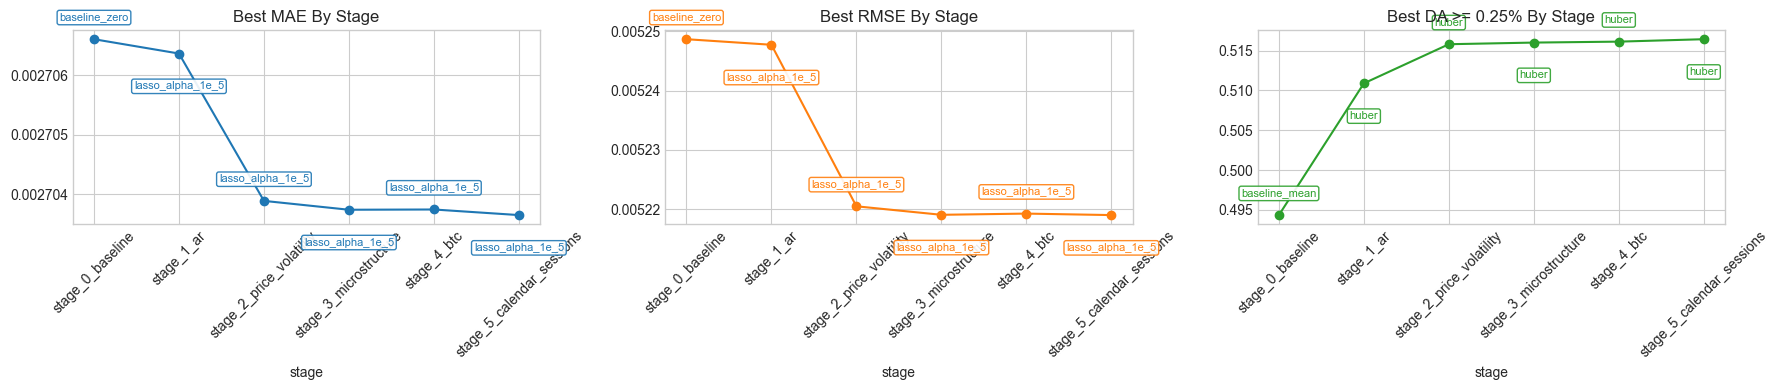

In [83]:
def format_model_label(row):
    model_family = row.get("model_family", "")
    stage = row.get("stage", "")
    model_id = row.get("model_id", "")
    if model_family:
        return model_family
    return model_id.removeprefix(f"{stage}_")


def annotate_stage_models(ax, data, metric, color="black"):
    for x_pos, (_, row) in enumerate(data.iterrows()):
        y_offset = 12 if x_pos % 2 == 0 else -20
        va = "bottom" if y_offset > 0 else "top"
        ax.annotate(
            format_model_label(row),
            xy=(x_pos, row[metric]),
            xytext=(0, y_offset),
            textcoords="offset points",
            ha="center",
            va=va,
            fontsize=8,
            color=color,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.9),
        )


fig, axes = plt.subplots(1, 3, figsize=(18, 4))

best_mae_by_stage.plot(x="stage", y="MAE", marker="o", ax=axes[0], legend=False)
annotate_stage_models(axes[0], best_mae_by_stage, "MAE", color="tab:blue")
axes[0].set_title("Best MAE By Stage")
axes[0].tick_params(axis="x", rotation=45)

best_mae_by_stage.plot(x="stage", y="RMSE", marker="o", ax=axes[1], legend=False, color="tab:orange")
annotate_stage_models(axes[1], best_mae_by_stage, "RMSE", color="tab:orange")
axes[1].set_title("Best RMSE By Stage")
axes[1].tick_params(axis="x", rotation=45)

best_da_by_stage.plot(x="stage", y="Direction_Accuracy_025", marker="o", ax=axes[2], legend=False, color="tab:green")
annotate_stage_models(axes[2], best_da_by_stage, "Direction_Accuracy_025", color="tab:green")
axes[2].set_title("Best DA >= 0.25% By Stage")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()

## Per-Horizon Best Metrics And Factors


=== Horizon 10 minutes ===


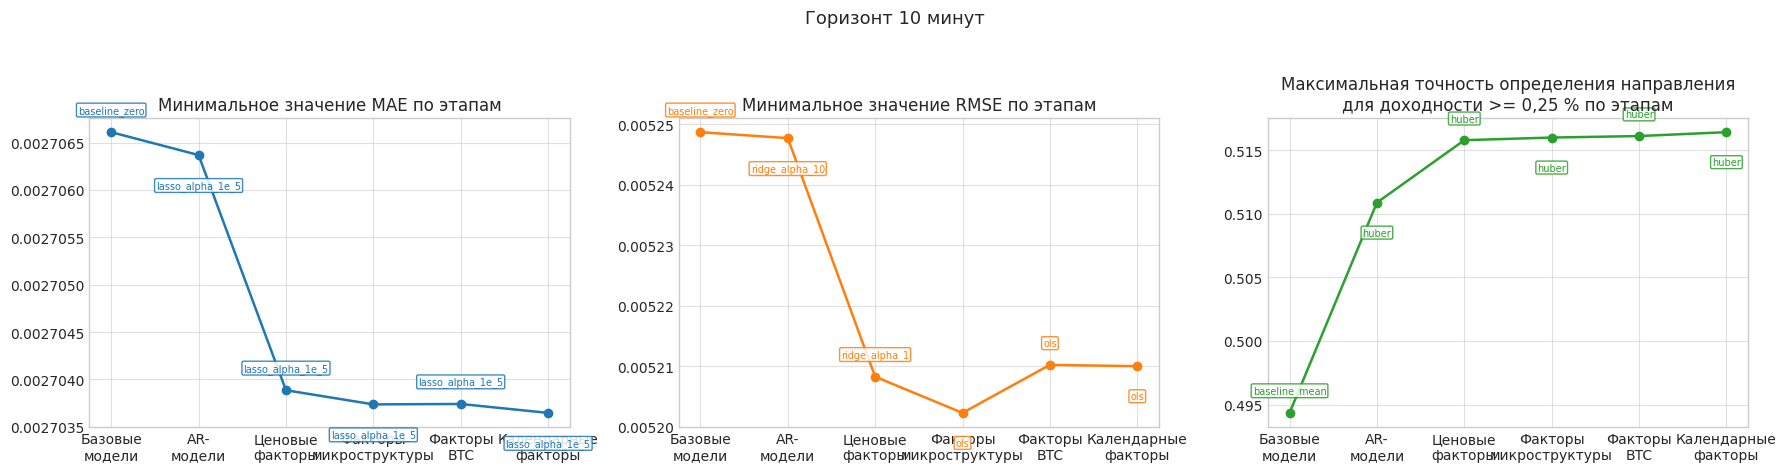

Best models and factors


,winner_by,model_id,stage,model_family,metric_value,n_features,feature_set,features
0,best_MAE,stage_5_calendar_sessions_006_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,0.002704,21,baseline_zero+ar_5+trend_volatility+trades_only+btc_returns_only+all_calendar_sessions,"[ada_log_return_lag_1, ada_log_return_lag_2, ada_log_return_lag_3, ada_log_return_lag_5, ada_cum_return_30m, ada_cum_return_60m, ada_return_std_20m, ada_return_std_60m, ada_rea..."
1,best_RMSE,stage_3_microstructure_040_ols,stage_3_microstructure,ols,0.005202,45,baseline_zero+ar_10+all_price_volatility+all_microstructure,"[ada_log_return_lag_1, ada_log_return_lag_2, ada_log_return_lag_3, ada_log_return_lag_5, ada_log_return_lag_10, ada_cum_return_30m, ada_cum_return_60m, ada_return_acceleration_..."
2,best_Direction_Accuracy_025,stage_5_calendar_sessions_030_huber,stage_5_calendar_sessions,huber,0.516425,35,baseline_zero+ar_5+trend_volatility_efficiency+all_microstructure+btc_efficiency_only+all_calendar_sessions,"[ada_log_return_lag_1, ada_log_return_lag_2, ada_log_return_lag_3, ada_log_return_lag_5, ada_cum_return_30m, ada_cum_return_60m, ada_return_std_20m, ada_return_std_60m, ada_rea..."



=== Horizon 20 minutes ===


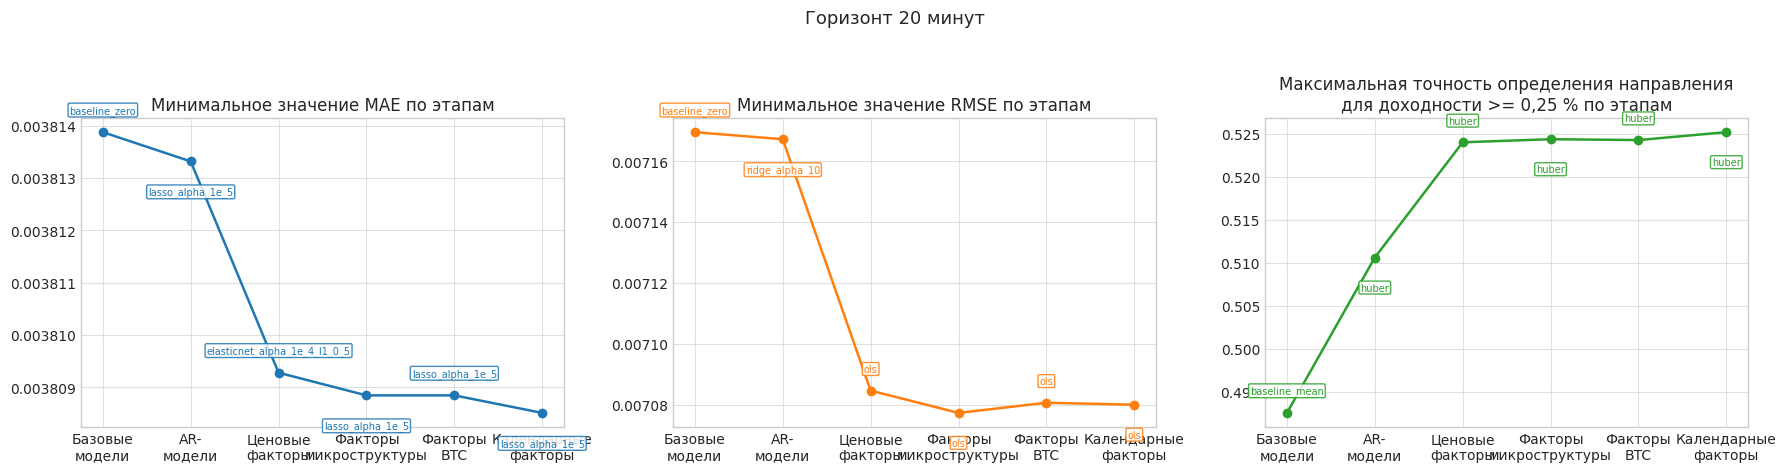

Best models and factors


,winner_by,model_id,stage,model_family,metric_value,n_features,feature_set,features
0,best_MAE,stage_5_calendar_sessions_009_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,0.003809,33,baseline_zero+ar_10+trend_volatility_efficiency+all_microstructure+btc_returns_only+sessions,"[ada_log_return_lag_1, ada_log_return_lag_2, ada_log_return_lag_3, ada_log_return_lag_5, ada_log_return_lag_10, ada_cum_return_30m, ada_cum_return_60m, ada_return_std_20m, ada_..."
1,best_RMSE,stage_3_microstructure_024_ols,stage_3_microstructure,ols,0.007077,45,baseline_zero+ar_10+all_price_volatility+all_microstructure,"[ada_log_return_lag_1, ada_log_return_lag_2, ada_log_return_lag_3, ada_log_return_lag_5, ada_log_return_lag_10, ada_cum_return_30m, ada_cum_return_60m, ada_return_acceleration_..."
2,best_Direction_Accuracy_025,stage_5_calendar_sessions_019_huber,stage_5_calendar_sessions,huber,0.525176,36,baseline_zero+ar_10+all_price_volatility+concentration_only+btc_efficiency_only+time_of_day,"[ada_log_return_lag_1, ada_log_return_lag_2, ada_log_return_lag_3, ada_log_return_lag_5, ada_log_return_lag_10, ada_cum_return_30m, ada_cum_return_60m, ada_return_acceleration_..."



=== Horizon 30 minutes ===


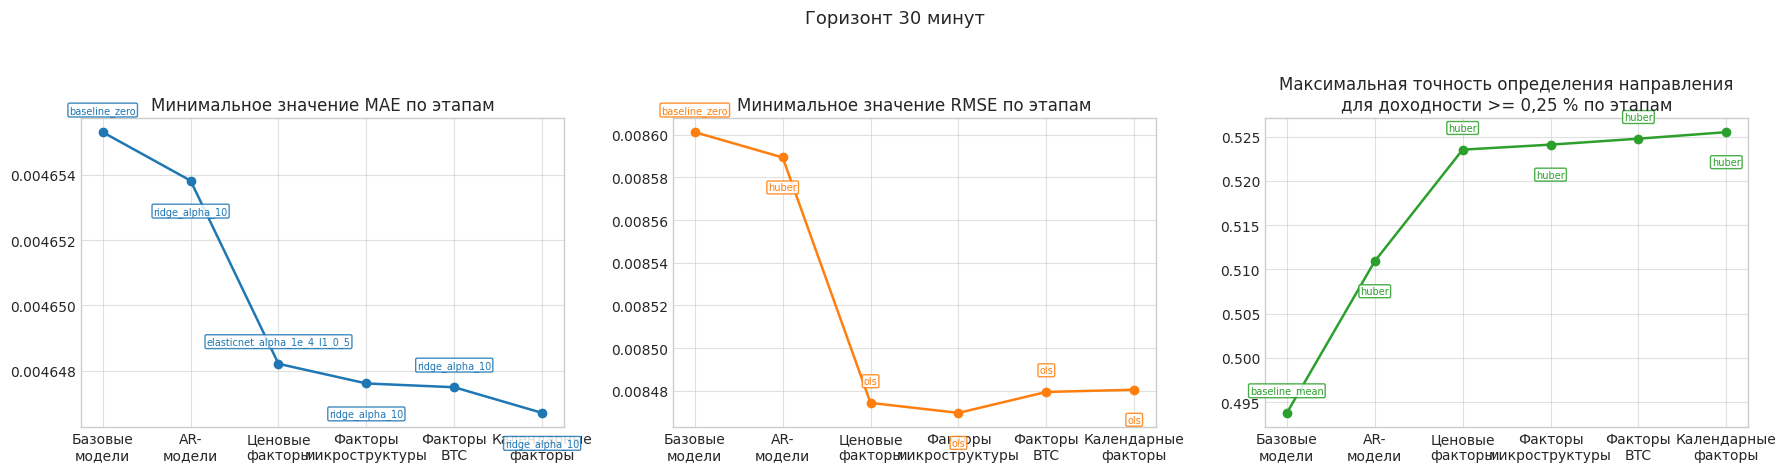

Best models and factors


,winner_by,model_id,stage,model_family,metric_value,n_features,feature_set,features
0,best_MAE,stage_5_calendar_sessions_009_ridge_alpha_10,stage_5_calendar_sessions,ridge_alpha_10,0.004647,22,baseline_zero+ar_5+trend_volatility_efficiency+concentration_only+all_btc+sessions,"[ada_log_return_lag_1, ada_log_return_lag_2, ada_log_return_lag_3, ada_log_return_lag_5, ada_cum_return_30m, ada_cum_return_60m, ada_return_std_20m, ada_return_std_60m, ada_rea..."
1,best_RMSE,stage_3_microstructure_047_ols,stage_3_microstructure,ols,0.008470,36,baseline_zero+ar_10+all_price_volatility+aggression_concentration,"[ada_log_return_lag_1, ada_log_return_lag_2, ada_log_return_lag_3, ada_log_return_lag_5, ada_log_return_lag_10, ada_cum_return_30m, ada_cum_return_60m, ada_return_acceleration_..."
2,best_Direction_Accuracy_025,stage_5_calendar_sessions_029_huber,stage_5_calendar_sessions,huber,0.525509,29,baseline_zero+ar_5+candle_geometry+aggression_concentration+btc_volatility_only+day_sessions,"[ada_log_return_lag_1, ada_log_return_lag_2, ada_log_return_lag_3, ada_log_return_lag_5, ada_upper_wick_5m, ada_upper_wick_30m, ada_lower_wick_5m, ada_lower_wick_60m, ada_log_r..."


In [84]:
from IPython.display import display

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Segoe UI", "Liberation Sans"]
plt.rcParams["axes.unicode_minus"] = False

STAGE_LABELS_RU = {
    "stage_0_baseline": "\u0411\u0430\u0437\u043e\u0432\u044b\u0435\n\u043c\u043e\u0434\u0435\u043b\u0438",
    "stage_1_ar": "AR-\n\u043c\u043e\u0434\u0435\u043b\u0438",
    "stage_2_price_volatility": "\u0426\u0435\u043d\u043e\u0432\u044b\u0435\n\u0444\u0430\u043a\u0442\u043e\u0440\u044b",
    "stage_3_microstructure": "\u0424\u0430\u043a\u0442\u043e\u0440\u044b\n\u043c\u0438\u043a\u0440\u043e\u0441\u0442\u0440\u0443\u043a\u0442\u0443\u0440\u044b",
    "stage_4_btc": "\u0424\u0430\u043a\u0442\u043e\u0440\u044b\nBTC",
    "stage_5_calendar_sessions": "\u041a\u0430\u043b\u0435\u043d\u0434\u0430\u0440\u043d\u044b\u0435\n\u0444\u0430\u043a\u0442\u043e\u0440\u044b",
}
STAGE_ORDER = list(STAGE_LABELS_RU)
STAGE_ORDER_MAP = {stage: i for i, stage in enumerate(STAGE_ORDER)}


def find_project_root(start=None):
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "build_price_feature_day.py").exists():
            return candidate
    return Path.cwd().resolve()


PROJECT_ROOT = find_project_root()
EXPERIMENT_DIR = PROJECT_ROOT / "analysis" / "target_10_model_experiments"

HORIZON_RESULT_DIRS = {
    10: [
        EXPERIMENT_DIR / "results" / "target_10" / "latest",
        EXPERIMENT_DIR / "results" / "latest",
        Path("results/latest"),
    ],
    20: [
        EXPERIMENT_DIR / "results" / "target_20" / "latest",
        EXPERIMENT_DIR / "analysis" / "target_10_model_experiments" / "results" / "target_20" / "latest",
        PROJECT_ROOT / "analysis" / "target_20_model_experiments" / "results" / "latest",
        Path("results/target_20/latest"),
    ],
    30: [
        EXPERIMENT_DIR / "results" / "target_30" / "latest",
        EXPERIMENT_DIR / "analysis" / "target_10_model_experiments" / "results" / "target_30" / "latest",
        PROJECT_ROOT / "analysis" / "target_30_model_experiments" / "results" / "latest",
        Path("results/target_30/latest"),
    ],
}


S3_BUCKET = "binance-data-downloader"
RESULT_FILENAMES = ["experiment_results.parquet", "stage_selection.parquet", "run_config.json"]
LOCAL_HORIZON_RESULTS_ROOT = EXPERIMENT_DIR / "results"


def first_existing_results_dir(candidates):
    for candidate in candidates:
        if (candidate / "experiment_results.parquet").exists():
            return candidate
    return None


def download_horizon_results_from_s3(horizon):
    import boto3

    local_dir = LOCAL_HORIZON_RESULTS_ROOT / f"target_{horizon}" / "latest"
    local_dir.mkdir(parents=True, exist_ok=True)
    s3 = boto3.client("s3")
    s3_prefix = f"dataset_target_{horizon}/model_experiments/latest"

    for filename in RESULT_FILENAMES:
        s3_key = f"{s3_prefix}/{filename}"
        local_path = local_dir / filename
        print(f"Downloading s3://{S3_BUCKET}/{s3_key} -> {local_path}")
        s3.download_file(S3_BUCKET, s3_key, str(local_path))

    return local_dir


def get_horizon_results_dir(horizon, candidates):
    horizon_dir = first_existing_results_dir(candidates)
    if horizon_dir is not None:
        return horizon_dir

    try:
        return download_horizon_results_from_s3(horizon)
    except Exception as exc:
        print(f"Could not download horizon {horizon} results from S3: {exc}")
        return None


def model_label(row):
    return row["model_family"] if row.get("model_family") else row["model_id"]


def parse_features(value):
    if isinstance(value, str):
        return json.loads(value)
    return list(value or [])


def best_by_stage(frame, metric, higher_is_better=False):
    sort_cols = ["stage", metric, "n_features", "simplicity_rank", "model_id"]
    ascending = [True, not higher_is_better, True, True, True]
    if metric == "MAE":
        sort_cols.insert(2, "RMSE")
        ascending.insert(2, True)
    elif metric == "RMSE":
        sort_cols.insert(2, "MAE")
        ascending.insert(2, True)

    best = (
        frame.sort_values(sort_cols, ascending=ascending, na_position="last")
        .groupby("stage", as_index=False)
        .first()
    )
    best["stage_order"] = best["stage"].map(STAGE_ORDER_MAP)
    return best.sort_values("stage_order")


def global_best_models(frame):
    specs = {
        "best_MAE": (
            ["MAE", "RMSE", "n_features", "simplicity_rank", "model_id"],
            [True, True, True, True, True],
            "MAE",
        ),
        "best_RMSE": (
            ["RMSE", "MAE", "n_features", "simplicity_rank", "model_id"],
            [True, True, True, True, True],
            "RMSE",
        ),
        "best_Direction_Accuracy_025": (
            ["Direction_Accuracy_025", "n_features", "simplicity_rank", "model_id"],
            [False, True, True, True],
            "Direction_Accuracy_025",
        ),
    }

    rows = []
    for winner_by, (sort_cols, ascending, metric) in specs.items():
        row = frame.sort_values(sort_cols, ascending=ascending, na_position="last").iloc[0]
        rows.append(
            {
                "winner_by": winner_by,
                "model_id": row["model_id"],
                "stage": row["stage"],
                "model_family": row["model_family"],
                "metric_value": row[metric],
                "n_features": row["n_features"],
                "feature_set": row["feature_set"],
                "features": parse_features(row["features"]),
            }
        )
    return pd.DataFrame(rows)


def plot_horizon(frame, horizon):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharex=True)
    metric_specs = [
        ("MAE", False, "\u041c\u0438\u043d\u0438\u043c\u0430\u043b\u044c\u043d\u043e\u0435 \u0437\u043d\u0430\u0447\u0435\u043d\u0438\u0435 MAE \u043f\u043e \u044d\u0442\u0430\u043f\u0430\u043c", "tab:blue"),
        ("RMSE", False, "\u041c\u0438\u043d\u0438\u043c\u0430\u043b\u044c\u043d\u043e\u0435 \u0437\u043d\u0430\u0447\u0435\u043d\u0438\u0435 RMSE \u043f\u043e \u044d\u0442\u0430\u043f\u0430\u043c", "tab:orange"),
        (
            "Direction_Accuracy_025",
            True,
            "\u041c\u0430\u043a\u0441\u0438\u043c\u0430\u043b\u044c\u043d\u0430\u044f \u0442\u043e\u0447\u043d\u043e\u0441\u0442\u044c \u043e\u043f\u0440\u0435\u0434\u0435\u043b\u0435\u043d\u0438\u044f \u043d\u0430\u043f\u0440\u0430\u0432\u043b\u0435\u043d\u0438\u044f\n\u0434\u043b\u044f \u0434\u043e\u0445\u043e\u0434\u043d\u043e\u0441\u0442\u0438 >= 0,25 % \u043f\u043e \u044d\u0442\u0430\u043f\u0430\u043c",
            "tab:green",
        ),
    ]

    for ax, (metric, higher_is_better, title, color) in zip(axes, metric_specs):
        best = best_by_stage(frame, metric, higher_is_better=higher_is_better)
        ax.plot(best["stage_order"], best[metric], marker="o", linewidth=1.8, color=color)
        for index, (_, row) in enumerate(best.iterrows()):
            offset = 12 if index % 2 == 0 else -18
            ax.annotate(
                model_label(row),
                xy=(row["stage_order"], row[metric]),
                xytext=(0, offset),
                textcoords="offset points",
                ha="center",
                va="bottom" if offset > 0 else "top",
                fontsize=7,
                color=color,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec=color, alpha=0.85),
            )
        ax.set_title(title)
        ax.set_xticks(range(len(STAGE_ORDER)))
        ax.set_xticklabels([STAGE_LABELS_RU[stage] for stage in STAGE_ORDER])
        ax.grid(True, alpha=0.6)

    fig.suptitle(f"\u0413\u043e\u0440\u0438\u0437\u043e\u043d\u0442 {horizon} \u043c\u0438\u043d\u0443\u0442", y=1.04, fontsize=13)
    fig.tight_layout()
    return fig


missing_horizons = []
for horizon, candidates in HORIZON_RESULT_DIRS.items():
    horizon_dir = get_horizon_results_dir(horizon, candidates)
    if horizon_dir is None:
        missing_horizons.append(horizon)
        continue

    horizon_results = pd.read_parquet(horizon_dir / "experiment_results.parquet")
    print(f"\n=== Horizon {horizon} minutes ===")
    display(plot_horizon(horizon_results, horizon))
    plt.close("all")

    print("Best models and factors")
    display(global_best_models(horizon_results))

if missing_horizons:
    print("Missing local results for horizons:", missing_horizons)


## Added Block Informativeness

In [85]:
block_summary = (
    results.loc[results["stage"].ne("stage_0_baseline")]
    .groupby(["stage", "added_block"], as_index=False)
    .agg(
        models=("model_id", "count"),
        best_MAE=("MAE", "min"),
        median_MAE=("MAE", "median"),
        best_RMSE=("RMSE", "min"),
        best_DA_025=("Direction_Accuracy_025", "max"),
        median_DA_025=("Direction_Accuracy_025", "median"),
        best_OOS_R2=("OOS_R2", "max"),
        median_delta_MAE=("delta_MAE", "median"),
        median_delta_RMSE=("delta_RMSE", "median"),
        median_delta_DA_025=("delta_DA_025", "median"),
    )
    .sort_values(["stage", "best_MAE", "best_RMSE"])
)

block_summary

,stage,added_block,models,best_MAE,median_MAE,best_RMSE,best_DA_025,median_DA_025,best_OOS_R2,median_delta_MAE,median_delta_RMSE,median_delta_DA_025
3,stage_1_ar,ar_5,8,0.002706,0.002706,0.005248,0.509116,0.509077,0.000375,-1.775819e-07,-9.620347e-07,0.509077
1,stage_1_ar,ar_10,8,0.002706,0.002706,0.005248,0.510883,0.509018,0.000365,-1.661461e-07,-9.479931e-07,0.509018
4,stage_1_ar,ar_all,8,0.002706,0.002706,0.005248,0.510883,0.509018,0.000365,-1.661461e-07,-9.479931e-07,0.509018
2,stage_1_ar,ar_3,8,0.002707,0.002707,0.005249,0.508437,0.508196,-0.000065,-4.771908e-08,3.460786e-07,0.508196
0,stage_1_ar,ar_1,8,0.002707,0.002707,0.005249,0.505990,0.505934,-0.000065,3.077036e-07,2.354712e-06,0.505934
11,stage_2_price_volatility,trend_volatility,16,0.002704,0.002705,0.005218,0.514905,0.513876,0.011631,-1.554786e-06,-2.959431e-05,0.004789
12,stage_2_price_volatility,trend_volatility_efficiency,16,0.002704,0.002705,0.005217,0.514895,0.513844,0.012170,-1.718173e-06,-3.039044e-05,0.004937
10,stage_2_price_volatility,trend,16,0.002704,0.002704,0.005234,0.514594,0.513999,0.005409,-2.144024e-06,-1.020546e-05,0.005282
6,stage_2_price_volatility,all_price_volatility,16,0.002704,0.002708,0.005208,0.515795,0.506771,0.015345,1.754410e-06,-3.824124e-05,-0.001991
9,stage_2_price_volatility,price_deviation,16,0.002705,0.002707,0.005248,0.514058,0.505208,0.000415,4.442328e-07,-5.285076e-08,-0.003460


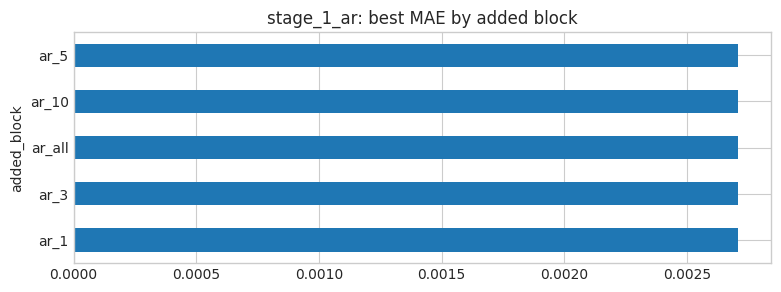

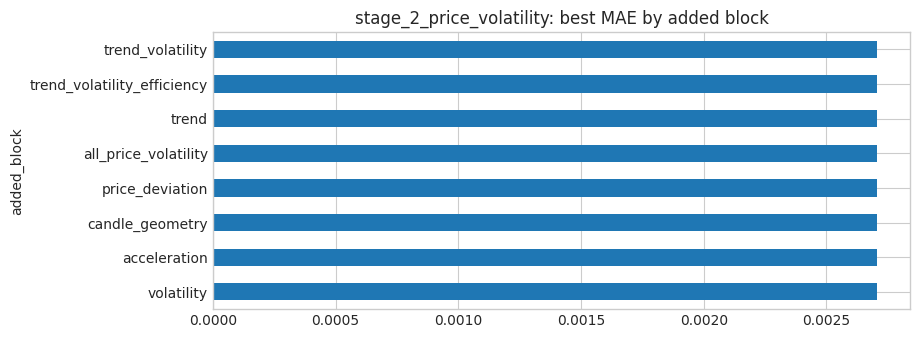

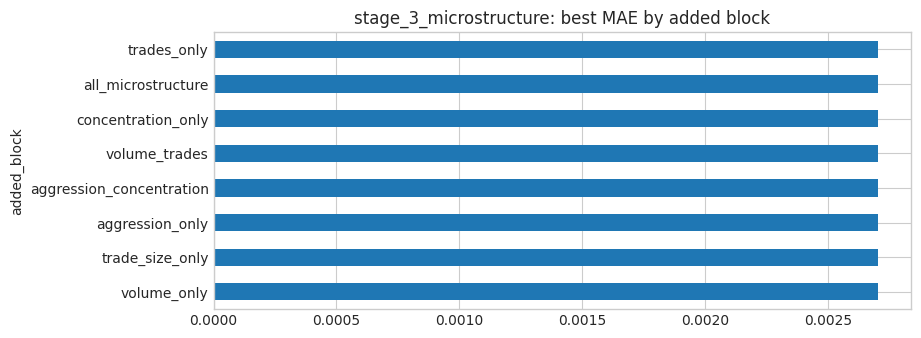

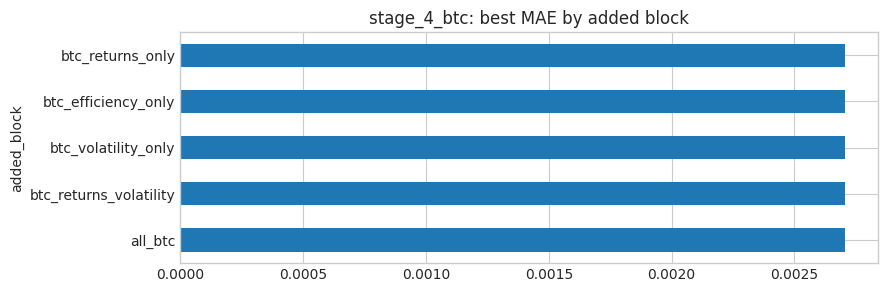

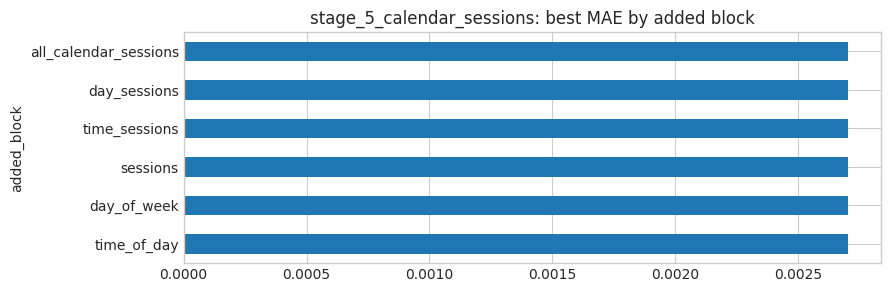

In [86]:
for stage, frame in block_summary.groupby("stage"):
    top_blocks = frame.sort_values("best_MAE").head(8)
    ax = top_blocks.plot.barh(
        x="added_block",
        y="best_MAE",
        figsize=(9, max(3, len(top_blocks) * 0.45)),
        legend=False,
        title=f"{stage}: best MAE by added block",
    )
    ax.invert_yaxis()
    plt.show()

## Selected Models By Stage

In [87]:
selected = results.loc[results["selected_for_next_stage"]].copy()
selected.sort_values(["stage", "rank_A", "rank_B"])[display_cols + ["rank_A", "rank_B", "selection_reason", "previous_model", "added_block"]]

,model_id,stage,model_family,feature_set,n_features,MAE,RMSE,Direction_Accuracy,Direction_Accuracy_025,DA_025_coverage,OOS_R2,Pearson_corr,rank_A,rank_B,selection_reason,previous_model,added_block
0,stage_0_baseline_001_baseline_zero,stage_0_baseline,baseline_zero,baseline_zero,0,0.002707,0.005249,NaN,0.000000,0.385474,0.000000,NaN,1,2,top_A_top_B,NaN,baseline_zero
1,stage_0_baseline_002_baseline_mean,stage_0_baseline,baseline_mean,baseline_mean,0,0.002707,0.005249,0.494219,0.494339,0.385474,-0.000022,NaN,2,1,top_A_top_B,NaN,baseline_mean
22,stage_1_ar_003_lasso_alpha_1e_5,stage_1_ar,lasso_alpha_1e_5,baseline_zero+ar_5,4,0.002706,0.005248,0.507236,0.508634,0.385474,0.000358,0.020965,1,16,top_A,stage_0_baseline_001_baseline_zero,ar_5
30,stage_1_ar_004_lasso_alpha_1e_5,stage_1_ar,lasso_alpha_1e_5,baseline_zero+ar_10,5,0.002706,0.005248,0.507236,0.508634,0.385474,0.000358,0.020965,2,17,top_A,stage_0_baseline_001_baseline_zero,ar_10
38,stage_1_ar_005_lasso_alpha_1e_5,stage_1_ar,lasso_alpha_1e_5,baseline_zero+ar_all,5,0.002706,0.005248,0.507236,0.508634,0.385474,0.000358,0.020965,3,18,top_A,stage_0_baseline_001_baseline_zero,ar_all
18,stage_1_ar_003_ols,stage_1_ar,ols,baseline_zero+ar_5,4,0.002706,0.005248,0.507641,0.509116,0.385474,0.000375,0.022370,7,3,top_B,stage_0_baseline_001_baseline_zero,ar_5
33,stage_1_ar_004_huber,stage_1_ar,huber,baseline_zero+ar_10,5,0.002707,0.005248,0.508241,0.510883,0.385474,0.000324,0.024483,25,1,top_B,stage_0_baseline_001_baseline_zero,ar_10
41,stage_1_ar_005_huber,stage_1_ar,huber,baseline_zero+ar_all,5,0.002707,0.005248,0.508241,0.510883,0.385474,0.000324,0.024483,26,2,top_B,stage_0_baseline_001_baseline_zero,ar_all
86,stage_2_price_volatility_006_lasso_alpha_1e_5,stage_2_price_volatility,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility,10,0.002704,0.005220,0.514038,0.514068,0.385474,0.010717,0.130613,1,20,top_A,stage_1_ar_003_ols,trend_volatility
158,stage_2_price_volatility_015_lasso_alpha_1e_5,stage_2_price_volatility,lasso_alpha_1e_5,baseline_zero+ar_10+trend_volatility,11,0.002704,0.005220,0.513825,0.513428,0.385474,0.010716,0.130449,2,54,top_A,stage_1_ar_004_lasso_alpha_1e_5,trend_volatility


## Model Family Diagnostics

In [88]:
family_summary = (
    results.groupby(["stage", "model_family"], as_index=False)
    .agg(
        models=("model_id", "count"),
        best_MAE=("MAE", "min"),
        median_MAE=("MAE", "median"),
        best_DA_025=("Direction_Accuracy_025", "max"),
        median_DA_025=("Direction_Accuracy_025", "median"),
        best_OOS_R2=("OOS_R2", "max"),
        total_fit_time=("fit_time", "sum"),
    )
    .sort_values(["stage", "best_MAE"])
)

family_summary

,stage,model_family,models,best_MAE,median_MAE,best_DA_025,median_DA_025,best_OOS_R2,total_fit_time
1,stage_0_baseline,baseline_zero,1,0.002707,0.002707,0.000000,0.000000,0.000000,0.000001
0,stage_0_baseline,baseline_mean,1,0.002707,0.002707,0.494339,0.494339,-0.000022,0.000690
5,stage_1_ar,lasso_alpha_1e_5,5,0.002706,0.002706,0.508634,0.508634,0.000358,2.761176
9,stage_1_ar,ridge_alpha_10,5,0.002706,0.002706,0.509116,0.509018,0.000375,2.501939
8,stage_1_ar,ridge_alpha_1,5,0.002706,0.002706,0.509116,0.509018,0.000375,2.394722
7,stage_1_ar,ridge_alpha_0_1,5,0.002706,0.002706,0.509116,0.509018,0.000375,2.399623
6,stage_1_ar,ols,5,0.002706,0.002706,0.509116,0.509018,0.000375,2.918789
2,stage_1_ar,elasticnet_alpha_1e_4_l1_0_5,5,0.002707,0.002707,0.506926,0.506926,-0.000034,3.222073
3,stage_1_ar,huber,5,0.002707,0.002707,0.510883,0.509037,0.000324,15.280554
4,stage_1_ar,lasso_alpha_1e_4,5,0.002707,0.002707,0.497312,0.497312,-0.000065,2.528736


## Notes For Interpretation

- `Direction_Accuracy_025` считается только на наблюдениях, где `abs(y_true) >= 0.25%`.
- `OOS_R2` считается относительно zero baseline.
- `delta_*` считается относительно `previous_model`, то есть показывает локальный эффект добавленного блока внутри цепочки отбора.
- Финальные победители по MAE и directional accuracy могут отличаться: это ожидаемо для задачи точечной доходности.